# 1. Introdução

# 2. Configurações

O ambiente de desenvolvimento utilizado é conhecido como Jupyter, um caderno de notas (notebooks) executado em navegadores que é útil para desenvolvimento, colaboração, compartilhamento e publicação de projetos de ciência e mineração de dados.

Os notebooks são compostos por células de pelo menos dois tipos: célula de código-fonte, onde é possível fazer a execução de scripts na linguagem Python (apesar de existirem notebooks para outras linguagens), e Markdown, uma linguagem de marcação que possibilita a estilização de texto plano, disponibilizando assim um ambiente organizado, explicativo e replicável.

O ambiente Jupyter pode ser encontrado e executado de duas formas:
- Local: utiliza os recursos computacionais da máquina do usuário, necessitando de instalação e configuração através de gerenciadores de pacotes, como Pip ou Conda.
- Nuvem: utiliza os recursos computacionais disponibilizados por um serviço dedicado, sem necessidade de instalação e configuração, sendo os mais conhecidos o Google Colab, Kaggle Kernels, Noteable, Azure Notebooks, e muito mais.

O Google Colab é um ambiente baseado em notebooks do Jupyter executado em nuvem, e será usado para a execução proposta neste documento. As células de código abaixo possuem o símbolo `[]`, além de possuírem numeração de linha. Para executá-las, posicione o cursor do mouse sobre `[]` e pressione o botão de *play* `▶` que irá aparecer no lugar. Uma alternativa para essa execução é selecionar a célula e usar `Ctrl+Enter`.

## 2.1. Importação dos pacotes

Aqui serão importados os pacotes que vamos utilizar ao longo da execução. No Google Colab, todos já estão instalados por padrão.

- `numpy`: análise numérica de dados.
- `pandas`: manipulação de dados tabulares.
- `matplotlib`: visualização de dados.
- `nltk`: processamento de linguagem natural tradicional.
- `emoji`: conversão de emojis para texto descritivo.
- `tensorflow` / `keras`: aprendizado profundo (redes neurais).
- `scikit-learn`: rotinas de aprendizado de máquina e métricas de avaliação.

In [1]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import emoji

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer
from sklearn.metrics import (
    cohen_kappa_score, f1_score, mean_absolute_error,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


2026-08-22 22:10:11.190841: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-22 22:10:11.199805: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787447411.209905   79948 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787447411.213468   79948 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787447411.221544   79948 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 2.2. Downloads

Todos os arquivos externos necessários são baixados aqui. Se o arquivo já existir no diretório, o download é ignorado.

In [2]:
# dataset B2W-Reviews01
if not os.path.exists("B2W-Reviews01.csv"):
    !wget -q "https://github.com/americanas-tech/b2w-reviews01/raw/refs/heads/main/B2W-Reviews01.csv" -O B2W-Reviews01.csv
    print("B2W-Reviews01.csv baixado.")
else:
    print("B2W-Reviews01.csv já existe, pulando download.")

# embeddings NILC/fastText (subconjunto vocabulário B2W)
if not os.path.exists("cbow_s300_b2w.npz"):
    !gdown 1kqLW0fSydICJdakcLehVaYXWfGF9-tkO -O cbow_s300_b2w.npz
    print("cbow_s300_b2w.npz baixado.")
else:
    print("cbow_s300_b2w.npz já existe, pulando download.")

B2W-Reviews01.csv já existe, pulando download.
cbow_s300_b2w.npz já existe, pulando download.


# 3. Pipeline como um Processo KDD

**KDD** (*Knowledge Discovery in Databases*) é um processo interativo e iterativo para a identificação de padrões válidos, novos, potencialmente úteis e entendíveis de dados ([Fayyad et al. 1996](https://ojs.aaai.org/aimagazine/index.php/aimagazine/article/view/1230)). É composto por 5 fases:

1. **Seleção**: escolha de um conjunto ou subconjunto de variáveis e amostras de "dados-alvo" na qual a descoberta será performada.
2. **Pré-processamento**: aumento da qualidade dos dados por meio de remoção de ruídos e manipulação de dados ausentes.
3. **Transformação**: armazenamento e formatação dos dados em que a ferramenta de mineração será aplicada.
4. **Mineração de Dados**: exploração de padrões e regras de interesse em um forma de representação específica.
5. **Interpretação e Avaliação**: extração e visualização dos padrões e regras gerados, além da validação de sua capacidade de aprendizado.

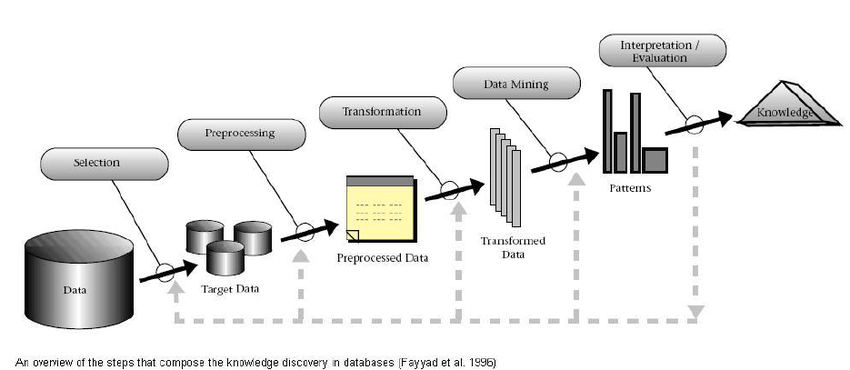

## 3.1. Seleção

A seleção trata da escolha do conjunto de dados alvo e escolha de subconjuntos de variáveis ou amostras na qual a descoberta de conhecimento será performada. Abordaremos aqui somente a subtarefa de carregamento dos dados.

O método `read_csv` do Pandas faz o carregamento de arquivos do tipo *Comma Separated Values* e retorna um objeto do tipo DataFrame, uma tabela que armazena e refencia os dados do arquivo por meio de suas colunas e índices. Os DataFrames são utilizados ao longo da manipulação de dados por conterem diversos atributos e métodos que facilitam este processo.

Vamos armazenar o DataFrame na variável `df`, utilizando o método `read_csv` passando dois parâmetros:

- `filepath_or_buffer`: o caminho para o arquivo csv a ser carregado.
- `sep`: o caractere de separação das colunas. Vamos utilizar a vírgula.

In [3]:
df = pd.read_csv(filepath_or_buffer="B2W-Reviews01.csv", sep=',')
df

/tmp/ipykernel_79948/1438051935.py:1: DtypeWarning: Columns (0: product_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath_or_buffer="B2W-Reviews01.csv", sep=',')


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-01 00:11:28,d0fb1ca69422530334178f5c8624aa7a99da47907c44de...,132532965,Notebook Asus Vivobook Max X541NA-GO472T Intel...,NaN,Informática,Notebook,Bom,4,Yes,Estou contente com a compra entrega rápida o ú...,1958.0,F,RJ
1,2018-01-01 00:13:48,014d6dc5a10aed1ff1e6f349fb2b059a2d3de511c7538a...,22562178,Copo Acrílico Com Canudo 500ml Rocie,NaN,Utilidades Domésticas,"Copos, Taças e Canecas","Preço imbatível, ótima qualidade",4,Yes,"Por apenas R$1994.20,eu consegui comprar esse ...",1996.0,M,SC
2,2018-01-01 00:26:02,44f2c8edd93471926fff601274b8b2b5c4824e386ae4f2...,113022329,Panela de Pressão Elétrica Philips Walita Dail...,philips walita,Eletroportáteis,Panela Elétrica,ATENDE TODAS AS EXPECTATIVA.,4,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,1984.0,M,SP
3,2018-01-01 00:35:54,ce741665c1764ab2d77539e18d0e4f66dde6213c9f0863...,113851581,Betoneira Columbus - Roma Brinquedos,roma jensen,Brinquedos,Veículos de Brinquedo,presente mais que desejado,4,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,1985.0,F,SP
4,2018-01-01 01:00:28,7d7b6b18dda804a897359276cef0ca252f9932bf4b5c8e...,131788803,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",lg,TV e Home Theater,TV,"Sem duvidas, excelente",5,Yes,"A entrega foi no prazo, as americanas estão de...",1994.0,M,MG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132368,2018-05-31 23:30:50,15f20e95ff44163f3175aaf67a5ae4a94d5030b409e521...,17962233,Carregador De Pilha Sony + 4 Pilhas Aa 2500mah,NaN,Câmeras e Filmadoras,Acessórios para Câmeras e Filmadoras,Ótimo produto!,5,Yes,"Vale muito, estou usando no controle do Xbox e...",1988.0,M,RS
132369,2018-05-31 23:42:25,def7cf9028b0673ab8bca3b1d06e085461fafb88cd48d9...,132631701,Mop Giratório Fit + Refil Extra - At Home,NaN,Utilidades Domésticas,Material de Limpeza,Sensacional,5,Yes,"Prático e barato, super indico o produto para ...",1979.0,F,SP
132370,2018-05-31 23:44:16,7bcbf542f5d7dd9a9a192a6805adba7a7a4c1ce3bf00df...,16095859,Fita Led 5m Rgb 3528 Siliconada Com 300 Leds C...,NaN,Automotivo,Iluminação,Ótimo produto,4,Yes,Chegou antes do prazo previsto e corresponde a...,1979.0,F,PR
132371,2018-05-31 23:46:48,e6fb0b19277d01c2a300c7837a105f3c369377e92f9c19...,6774907,Etiquetas Jurídicas Vade Mecum - Marca Fácil,marca facil,Papelaria,Material de Escritório,O produto não é bom.,1,No,"Material fraco, poderia ser melhor. Ficou deve...",1991.0,M,RJ


Ao longo do pré-processamento, vamos utilizar o DataFrame armazenado em `df`, que vai sofrer as devidas alterações até assumir um formato aceitável de ser passado para o algoritmo de aprendizado. A quantidade de linhas e colunas do DataFrame é expressa respectivamente por:

In [4]:
df.shape

(132373, 14)

Outra informação importante de ser destacada são os tipos de dados das colunas, dado por:

In [5]:
df.dtypes

submission_date              str
reviewer_id                  str
product_id                object
product_name                 str
product_brand                str
site_category_lv1            str
site_category_lv2            str
review_title                 str
overall_rating             int64
recommend_to_a_friend        str
review_text                  str
reviewer_birth_year      float64
reviewer_gender              str
reviewer_state               str
dtype: object

Antes de passar para as demais etapas do KDD que efetivamente alteram os dados carregados, vamos analisar as colunas no seu formato original.

In [6]:
df = df[["overall_rating", "review_text"]]
df

,overall_rating,review_text
0,4,Estou contente com a compra entrega rápida o ú...
1,4,"Por apenas R$1994.20,eu consegui comprar esse ..."
2,4,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...
3,4,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...
4,5,"A entrega foi no prazo, as americanas estão de..."
...,...,...
132368,5,"Vale muito, estou usando no controle do Xbox e..."
132369,5,"Prático e barato, super indico o produto para ..."
132370,4,Chegou antes do prazo previsto e corresponde a...
132371,1,"Material fraco, poderia ser melhor. Ficou deve..."


## 3.1.1. Análise exploratória dos dados

In [7]:
df["overall_rating"].info()

<class 'pandas.Series'>
RangeIndex: 132373 entries, 0 to 132372
Series name: overall_rating
Non-Null Count   Dtype
--------------   -----
132373 non-null  int64
dtypes: int64(1)
memory usage: 1.0 MB


In [8]:
counts_or = df["overall_rating"].value_counts()
counts_or

overall_rating
5    47955
4    32345
1    27369
3    16315
2     8389
Name: count, dtype: int64

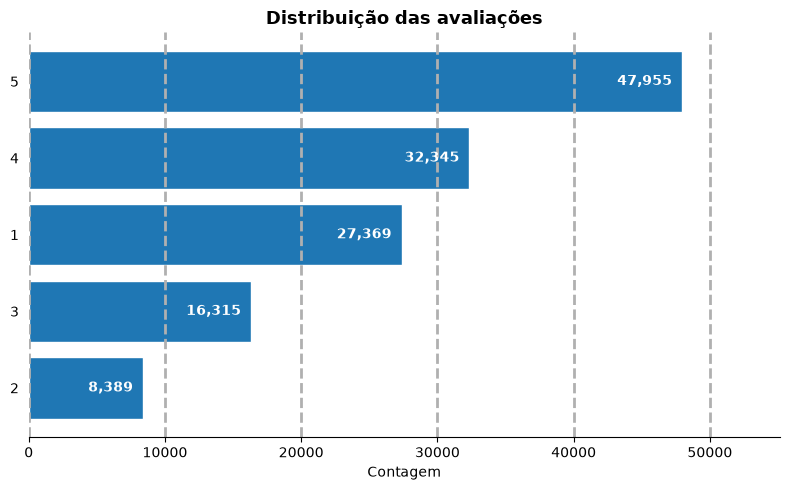

In [9]:
data = counts_or.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(data.index.astype(str), data.values, edgecolor="white")

for bar in bars:
    w = bar.get_width()
    ax.text(w - (data.values.max() * 0.015), bar.get_y() + bar.get_height() / 2,
            f"{w:,.0f}", va="center", ha="right", fontsize=10, color="white", weight="bold")

ax.set_xlabel("Contagem")
ax.set_title("Distribuição das avaliações", fontsize=13, weight="bold")

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False)
ax.set_xlim(0, data.values.max() * 1.15)
ax.grid(axis='x', linestyle="--", linewidth=2)

plt.tight_layout()

Em datasets de reviews, emojis e emoticons frequentemente carregam sentimento forte. Verificar sua presença é uma etapa de validação importante — determina se vale investir em conversão (demojize) ou se o dataset é predominantemente textual.

In [10]:
# emojis unicode
emoji_unicode = re.compile(
    r"[😀-🙏🌀-🗿🚀-🛿"
    r"🇠-🇿✂-➰Ⓜ-🉑"
    r"❤♥♡☺⭐★✌]+",
    flags=re.UNICODE
)

# emoticons em texto
emoji_text = re.compile(
    r"(?:[:;=8]['\-]?[)(DPpOo/\\|3\[\]])"
    r"|(?:<3|</3|S2|s2|xD|XD|:v)"
)

has_unicode = df["review_text"].str.contains(emoji_unicode, na=False)
has_text = df["review_text"].str.contains(emoji_text, na=False)
has_any = has_unicode | has_text

print(f"Reviews com emojis unicode: {has_unicode.sum():,} ({has_unicode.sum()/len(df)*100:.2f}%)")
print(f"Reviews com emoticons texto: {has_text.sum():,} ({has_text.sum()/len(df)*100:.2f}%)")
print(f"Total (qualquer tipo):      {has_any.sum():,} ({has_any.sum()/len(df)*100:.2f}%)")

if has_any.sum() > 0:
    print(f"Exemplos:")
    for _, row in df[has_any].sample(min(5, has_any.sum()), random_state=42).iterrows():
        print(f"  [{row["overall_rating"]}★] {row["review_text"][:150]}")

Reviews com emojis unicode: 137 (0.10%)
Reviews com emoticons texto: 1,248 (0.94%)
Total (qualquer tipo):      1,377 (1.04%)
Exemplos:
  [5★] Produdo espetacular, recomendo de olhos fechados!!!!❤
  [4★] Conjunto de ótima qualidade,entrega dentro do prazo,recomendo :)
  [5★] Qualidade de gravação é muito boa, o produto veio em perfeita condição e até agora não deu problema algum. Talvez se o cabo PS2 fosse um pouco mais lo
  [4★] Já fiz pão francês e integral e foi tudo bem, conforme o manual. O cheirinho de pão quando você acorda não tem preço... :)
  [1★] quem vai ser o maluco que vai comprar isso? XD Se eu n tenho como nem comprar o iphone x imagina a capinha dele XD


## 3.2. Pré-processamento

O pré-processamento remove ruído dos dados, mas cada transformação tem um custo. Em análise de sentimento, limpezas agressivas podem destruir exatamente o sinal que queremos capturar — especialmente nos casos de incoerência entre texto e nota.

Vamos ver o impacto de cada etapa antes de decidir o que aplicar.

Existem dezenas de técnicas de pré-processamento textual. As mais relevantes para classificação de sentimento em pt-BR:

| Técnica | O que faz | Quando usar |
|---|---|---|
| Remoção de duplicatas | Elimina textos idênticos | Sempre — evita leakage |
| Normalização de capitalização | Lowercase | Quase sempre (exceto transformers case-sensitive) |
| Remoção de stopwords | Remove palavras sem carga semântica | TF-IDF/BoW sim; embeddings/LSTM com cautela (negações!) |
| Lematização/Stemming | Reduz flexões ao radical | TF-IDF/BoW sim; embeddings pré-treinados não (desalinha vocabulário) |
| Conversão de emojis para texto | 😡 → "rosto com raiva" | Quando embeddings não cobrem emojis |
| Normalização de elongação | "muuuito" → "muito" | Texto informal (reviews, redes sociais) |
| Normalização de internetês | "vc" → "você", "tb" → "também" | Texto UGC em pt-BR (ver ferramenta Enelvo) |
| Correção ortográfica | Corrige typos | Quando ruído ortográfico é alto |
| Remoção/normalização de URLs e HTML | Substitui por token ou remove | Dados coletados da web |
| Data augmentation | Gera exemplos sintéticos | Dados escassos; ganho marginal no B2W (Amadeus & Branco, 2023) |
| Class weighting / focal loss | Compensa desbalanceamento | Classes com frequências muito diferentes |

Para aprofundamento: Jurafsky & Martin, *Speech and Language Processing* (cap. 2); survey "The Text Classification Pipeline" (arXiv:2501.00174).

Neste workshop aplicamos: remoção de ausentes e duplicatas, lowercase, conversão de emojis e normalização de elongação. As demais são discutidas mas **não aplicadas** — cada decisão tem um custo, e o pipeline com embeddings pré-treinados se beneficia de menos manipulação.

### 3.2.1. Dados ausentes

In [11]:
missing = df["review_text"].isna().sum()
print(f"Reviews com texto ausente: {missing} ({missing/len(df)*100:.2f}%)")

df = df.dropna(subset=["review_text"])
print(f"Dataset após remoção: {len(df):,} amostras")

Reviews com texto ausente: 3275 (2.47%)
Dataset após remoção: 129,098 amostras


### 3.2.2. Dados duplicados

Reviews duplicadas (texto idêntico) podem inflar artificialmente o desempenho se caírem no treino e no teste ao mesmo tempo.

In [12]:
duplicated = df["review_text"].duplicated().sum()
print(f"Reviews com texto duplicado: {duplicated:,} ({duplicated/len(df)*100:.2f}%)")

df = df.drop_duplicates(subset="review_text")
print(f"Dataset após remoção: {len(df):,} amostras")

Reviews com texto duplicado: 2,374 (1.84%)
Dataset após remoção: 126,724 amostras


### 3.2.3. Normalização de capitalização

Converter para minúsculas reduz a variabilidade do vocabulário ("Produto", "produto" e "PRODUTO" viram uma entrada só). Porém, perdemos ênfase em CAPS — que muitas vezes carrega sentimento forte.

In [13]:
# exemplos de ênfase em CAPS no dataset
caps_examples = df[df["review_text"].str.contains(r"\b[A-Z]{4,}\b", na=False)].head(5)
for _, row in caps_examples.iterrows():
    print(f"[{row['overall_rating']}★] {row['review_text'][:150]}")
    print()

[4★] SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANELAS ELÉTRICAS.  COSTUMO USAR OUTRA PANELA PARA COZIMENTO DE ARROZ (JAPONESA), MAS LEVA MUITO TEMPO,  +/- 

[4★] MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS DETALHES QUE TÊM!

[5★] produto mto bom, com essa garrafinha vc pode até servir água pro megazord. To pensando em vender minha tv pra comprar 1 garrafa dessa. RECOMENDO

[1★] MEU PRODUTO NAO FOI ENTREGUE E A AMERICANAS ESTA DESCONTANDO NA FATURA DO MEU CARTÃO

[5★] PRODUTO DE ÓTIMA QUALIDADE EU RECOMENDO MUITO ESSE CELULAR TEM UM ÓTIMO CUSTO BENEFICIO



In [14]:
df["review_text"] = df["review_text"].str.lower()
print("Capitalização normalizada.")
df[["review_text"]].head()

Capitalização normalizada.


,review_text
0,estou contente com a compra entrega rápida o ú...
1,"por apenas r$1994.20,eu consegui comprar esse ..."
2,supera em agilidade e praticidade outras panel...
3,meu filho amou! parece de verdade com tantos d...
4,"a entrega foi no prazo, as americanas estão de..."


### 3.2.4. O custo da remoção de stopwords

A lista padrão de stopwords em português do NLTK inclui a palavra **"não"**. Remover stopwords transforma *"não gostei"* em *"gostei"* — invertendo completamente o sentimento. Veja:

In [15]:
nltk.download("stopwords", quiet=True)
stopwords_pt = set(nltk.corpus.stopwords.words("portuguese"))

negacoes_na_lista = [w for w in sorted(stopwords_pt) if w.startswith("n")]
print(f"Palavras com 'n' na lista de stopwords: {negacoes_na_lista}")
print(f"\n'não' está na lista? {'não' in stopwords_pt}")

# demonstração do efeito
exemplo = "não gostei do produto, não recomendo"
sem_stopwords = " ".join([w for w in exemplo.split() if w not in stopwords_pt])
print(f"\nOriginal:       '{exemplo}'")
print(f"Sem stopwords:  '{sem_stopwords}'")

Palavras com 'n' na lista de stopwords: ['na', 'nas', 'nem', 'no', 'nos', 'nossa', 'nossas', 'nosso', 'nossos', 'num', 'numa', 'não', 'nós']

'não' está na lista? True

Original:       'não gostei do produto, não recomendo'
Sem stopwords:  'gostei produto, recomendo'


### 3.2.5. O custo da remoção de pontuação e emojis

Pontuação expressiva ("!!!", "...") e emojis carregam sentimento. São especialmente informativos nos casos de incoerência — um emoji de raiva ao lado de 5 estrelas é um sinal forte de ironia ou erro de input.

In [16]:
# exemplos com pontuação expressiva ou emojis
expressive = df[
    df["review_text"].str.contains(r"[!]{2,}|[.]{3,}|😡|😤|👎|💩|😍|❤️", na=False)
].sample(5, random_state=42)

for _, row in expressive.iterrows():
    print(f"[{row['overall_rating']}★] {row['review_text'][:150]}")
    print()

[5★] já havia escolhido o produto bem antes da compra e correspondeu a todas as minhas expectativas... nota 10..

[5★] smart tv excelente, produto de qualidade!! dentro das expectativas... e entrega muita rápida!!

[5★] o produto chegou intacto e antes do prazo!!!  livro para utilizar em estudo de casa, escritório, biblioteca privada, porque ele é pesado para levar pa

[3★] este produto muito bom, ótima qualidade e preço tbm!! super recomendo..

[5★] ótimo livro, excelente conteúdo, entrega rápida, antes do prazo e preço bom....



### 3.2.6. Conversão de emojis, emoticons e normalização de elongação

Emojis unicode são OOV para os embeddings NILC (treinados em texto puro). Converter para texto descritivo recupera parte desse sinal. Emoticons textuais (":)", "s2", "<3") também são convertidos para descritores legíveis. Elongações ("amoooo", "péssimoooo") criam variantes infinitas da mesma palavra — normalizamos para no máximo 2 caracteres repetidos.

In [17]:
# antes
sample_before = df[df["review_text"].str.contains(r"[😀-🙏]|(?<!\S):\)|(?<!\S)<3|(?<!\S)s2(?!\S)", na=False)]
if not sample_before.empty:
    print(f"Antes:  {sample_before.iloc[0]['review_text'][:150]}")

# conversão de emojis unicode para texto
df["review_text"] = df["review_text"].apply(
    lambda x: emoji.demojize(x, language="pt", delimiters=("", " "))
)

# conversão de emoticons textuais para descritores
EMOTICON_MAP = {
    ":)": "sorriso", ":-)": "sorriso", ":d": "riso", ":-d": "riso",
    ":(": "triste", ":-(": "triste", ":'(": "choro",
    ";)": "piscada", ";-)": "piscada",
    ":p": "língua", ":-p": "língua",
    "<3": "coração", "s2": "coração",
    "</3": "coração partido",
    "xd": "riso", ":v": "riso",
    ":o": "surpresa", ":-o": "surpresa",
    ":/": "indeciso", ":-/": "indeciso",
}

EMOTICON_PATTERN = re.compile(
    "|".join(
        rf"(?<!\S){re.escape(e)}(?!\S)"
        for e in sorted(EMOTICON_MAP, key=len, reverse=True)
    )
)

def replace_emoticons(text):
    return EMOTICON_PATTERN.sub(
        lambda m: f" {EMOTICON_MAP[m.group()]} ", text
    )

df["review_text"] = df["review_text"].apply(replace_emoticons)

# normalização de elongação (max 2 caracteres repetidos)
df["review_text"] = df["review_text"].apply(
    lambda x: re.sub(r"(.)\1{2,}", r"\1\1", x)
)

# depois
if not sample_before.empty:
    idx = sample_before.index[0]
    print(f"Depois: {df.loc[idx, 'review_text'][:150]}")

print(f"Transformações aplicadas: demojize + emoticons textuais + normalização de elongação.")


Antes:  não é todo dia q temos uma promoção dessas. aproveitei e comprei vários antes q o preço aumente. amei, nota 0 :)
Depois: não é todo dia q temos uma promoção dessas. aproveitei e comprei vários antes q o preço aumente. amei, nota 0  sorriso 
Transformações aplicadas: demojize + emoticons textuais + normalização de elongação.


### 3.2.7. Decisão de pré-processamento

Para este workshop aplicamos: **remoção de ausentes**, **remoção de duplicatas**, **lowercase**, **conversão de emojis para texto** e **normalização de elongação**. Stopwords, pontuação restante e demais caracteres são preservados — o modelo aprende a lidar com eles.

Isso vale para os Pipelines 2 (LSTM) e 3 (Gemini). O Pipeline 1 (TF-IDF) pode aplicar mais limpeza dentro da sua seção se necessário.

## 3.3. Pipeline 1: TF-IDF + Regressão Logística

O primeiro pipeline é o **baseline**: rápido de treinar, fácil de interpretar, e serve como referência para avaliar se um modelo mais complexo realmente agrega valor. Se o LSTM não bater o TF-IDF+LogReg, o custo extra de treino não se justifica.

A ideia é simples: representar cada review como um vetor de frequências de termos ponderadas (TF-IDF), e treinar uma regressão logística para prever a nota.

### 3.3.1. Divisão dos dados

Separamos os dados em três conjuntos:
- **Leaderboard** (~300 amostras, estratificado): usado para a competição. Vocês recebem apenas o texto, sem a nota.
- **Treino** (80% do restante): o modelo aprende a partir destes dados.
- **Teste** (20% do restante): avaliação local antes de submeter.

O `random_state` fixo garante que **todos os participantes trabalham com exatamente os mesmos conjuntos**.

In [18]:
RANDOM_STATE = 42
LEADERBOARD_SIZE = 300

# separar leaderboard (estratificado por estrela)
df_main, df_leaderboard = train_test_split(
    df,
    test_size=LEADERBOARD_SIZE,
    stratify=df["overall_rating"],
    random_state=RANDOM_STATE
)

# separar treino e teste
df_train, df_test = train_test_split(
    df_main,
    test_size=0.2,
    stratify=df_main["overall_rating"],
    random_state=RANDOM_STATE
)

df_leaderboard = df_leaderboard.assign(review_id=df_leaderboard.index).reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Treino:      {len(df_train):,} amostras")
print(f"Teste:       {len(df_test):,} amostras")
print(f"Leaderboard: {len(df_leaderboard):,} amostras")
print(f"Distribuição no treino:")
print(df_train["overall_rating"].value_counts().sort_index())

Treino:      101,139 amostras
Teste:       25,285 amostras
Leaderboard: 300 amostras
Distribuição no treino:
overall_rating
1    19640
2     6378
3    12649
4    25369
5    37103
Name: count, dtype: int64


### 3.3.2. Vetorização TF-IDF

TF-IDF (**T**erm **F**requency — **I**nverse **D**ocument **F**requency) pondera cada termo pela sua relevância: palavras frequentes no documento mas raras no corpus recebem peso alto. O resultado é uma matriz esparsa de alta dimensionalidade.

Opcionalmente, podemos aplicar **LSA** (Latent Semantic Analysis) para reduzir a dimensionalidade e capturar tópicos latentes.

In [19]:
MAX_FEATURES = 50000  #@param {type: "integer"}
USE_LSA = False  #@param {type: "boolean"}
N_COMPONENTS = 100  #@param {type: "integer"}

tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(df_train["review_text"])
X_test_tfidf = tfidf.transform(df_test["review_text"])

if USE_LSA:
    lsa = make_pipeline(TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE), Normalizer())
    X_train_tfidf = lsa.fit_transform(X_train_tfidf)
    X_test_tfidf = lsa.transform(X_test_tfidf)
    print(f"LSA aplicado: {X_train_tfidf.shape[1]} componentes")
else:
    print(f"Sem LSA: {X_train_tfidf.shape[1]:,} features")

y_train_lr = df_train["overall_rating"].values
y_test_lr = df_test["overall_rating"].values

print(f"Matriz de treino: {X_train_tfidf.shape}")

Sem LSA: 50,000 features
Matriz de treino: (101139, 50000)


### 3.3.3. Treinamento e avaliação

A regressão logística é rápida e serve como piso: qualquer modelo mais sofisticado precisa superá-la para justificar sua complexidade.

/home/hellsdeur/Code/courses/plncc/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/hellsdeur/Code/courses/plncc/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


=== TF-IDF + Regressão Logística ===
QWK:      0.8187
Macro-F1: 0.5093
MAE:      0.5253

              precision    recall  f1-score   support

           1     0.7351    0.8943    0.8069      4910
           2     0.3966    0.1611    0.2292      1595
           3     0.4932    0.3542    0.4123      3162
           4     0.4480    0.3757    0.4087      6342
           5     0.6332    0.7559    0.6891      9276

    accuracy                         0.5997     25285
   macro avg     0.5412    0.5083    0.5093     25285
weighted avg     0.5741    0.5997    0.5780     25285



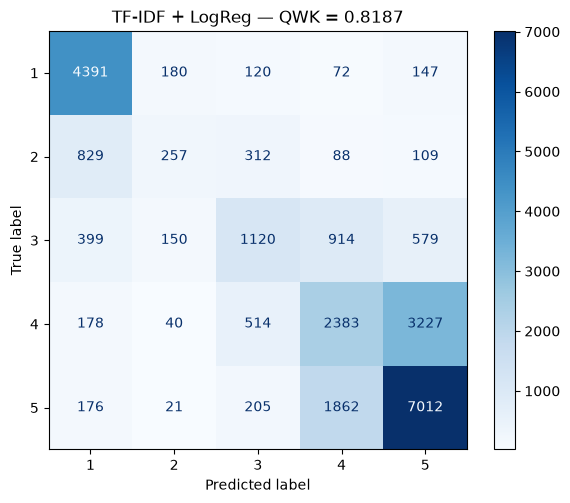

In [20]:
MAX_ITER = 1000  #@param {type: "integer"}
C_PARAM = 1.0  #@param {type: "number"}

lr_model = LogisticRegression(
    max_iter=MAX_ITER,
    C=C_PARAM,
    solver="lbfgs",
    multi_class="multinomial",
    random_state=RANDOM_STATE
)

lr_model.fit(X_train_tfidf, y_train_lr)
y_pred_lr = lr_model.predict(X_test_tfidf)

qwk_lr = cohen_kappa_score(y_test_lr, y_pred_lr, weights="quadratic")
f1_lr = f1_score(y_test_lr, y_pred_lr, average="macro")
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)

print(f"=== TF-IDF + Regressão Logística ===")
print(f"QWK:      {qwk_lr:.4f}")
print(f"Macro-F1: {f1_lr:.4f}")
print(f"MAE:      {mae_lr:.4f}")
print()
print(classification_report(y_test_lr, y_pred_lr, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_lr, y_pred_lr, ax=ax, cmap="Blues")
ax.set_title(f"TF-IDF + LogReg — QWK = {qwk_lr:.4f}")
plt.tight_layout()
plt.show()

### 3.3.4. Submissão (referência)

Este pipeline **não** entra no ranking premiável — serve como referência para comparação. O CSV é gerado no mesmo formato para que você possa verificar o QWK do baseline no leaderboard.

In [21]:
X_lb_tfidf = tfidf.transform(df_leaderboard["review_text"])
if USE_LSA:
    X_lb_tfidf = lsa.transform(X_lb_tfidf)

y_pred_lb_lr = lr_model.predict(X_lb_tfidf)

submission_lr = pd.DataFrame({
    "review_id": df_leaderboard["review_id"],
    "predicted_rating": y_pred_lb_lr,
    "pipeline_used": "tfidf_logreg"
})

submission_lr.to_csv("submission_tfidf_logreg.csv", index=False)
print(f"Submissão salva: submission_tfidf_logreg.csv ({len(submission_lr)} predições)")
submission_lr.head()

Submissão salva: submission_tfidf_logreg.csv (300 predições)


,review_id,predicted_rating,pipeline_used
0,92870,1,tfidf_logreg
1,46191,1,tfidf_logreg
2,17439,4,tfidf_logreg
3,97410,3,tfidf_logreg
4,129713,1,tfidf_logreg


## 3.4. Pipeline 2: Embeddings + LSTM

Word embeddings representam palavras como vetores densos em um espaço contínuo, onde palavras com significados semelhantes ficam próximas. Diferente do TF-IDF, que trata cada palavra como uma dimensão independente, embeddings capturam relações semânticas aprendidas a partir de grandes volumes de texto.

Vamos usar embeddings pré-treinados do projeto NILC (Núcleo Interinstitucional de Linguística Computacional), treinados com fastText sobre um corpus de português brasileiro. Esses vetores entram **congelados** na rede — o LSTM aprende a combinar representações que já carregam informação semântica, sem modificá-las.

### 3.4.1. Tokenização e padding

Para alimentar a rede neural, cada review precisa virar uma sequência de inteiros de comprimento fixo. O `Tokenizer` do Keras mapeia cada palavra a um índice numérico, e `pad_sequences` completa ou trunca cada sequência até o tamanho máximo.

In [22]:
VOCAB_SIZE = 50000  #@param {type: "integer"}
MAX_LEN = 100  #@param {type: "integer"}

tokenizer_lstm = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer_lstm.fit_on_texts(df_train["review_text"])

word_index = tokenizer_lstm.word_index
print(f"Vocabulário total: {len(word_index):,} palavras")
print(f"Vocabulário utilizado: {min(len(word_index), VOCAB_SIZE):,} palavras")

X_train_seq = pad_sequences(
    tokenizer_lstm.texts_to_sequences(df_train["review_text"]),
    maxlen=MAX_LEN, padding="post", truncating="post"
)
X_test_seq = pad_sequences(
    tokenizer_lstm.texts_to_sequences(df_test["review_text"]),
    maxlen=MAX_LEN, padding="post", truncating="post"
)

print(f"\nFormato de X_train_seq: {X_train_seq.shape}")
print(f"Formato de X_test_seq: {X_test_seq.shape}")

Vocabulário total: 44,590 palavras
Vocabulário utilizado: 44,590 palavras

Formato de X_train_seq: (101139, 100)
Formato de X_test_seq: (25285, 100)


As estrelas (1 a 5) precisam ser mapeadas para índices de classe (0 a 4) para o treinamento com `sparse_categorical_crossentropy`.

In [23]:
NUM_CLASSES = 5

y_train_lstm = df_train["overall_rating"].values - 1
y_test_lstm = df_test["overall_rating"].values - 1

print(f"Estrelas originais: {sorted(df_train['overall_rating'].unique())}")
print(f"Classes mapeadas:   {sorted(np.unique(y_train_lstm))}")

Estrelas originais: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Classes mapeadas:   [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


### 3.4.2. Embeddings pré-treinados

Os embeddings do NILC/fastText foram pré-processados para conter apenas o vocabulário presente no dataset B2W. Isso reduz o arquivo de >1 GB para poucos megabytes.

A célula a seguir carrega esse subconjunto e monta a **matriz de embeddings**: cada linha *i* contém o vetor da palavra com índice *i* no tokenizer. Palavras fora do vocabulário dos embeddings recebem vetor zero.

In [24]:
EMBEDDING_DIM = 300

embeddings_data = np.load("cbow_s300_b2w.npz", allow_pickle=True)
embeddings_dict = dict(zip(
    embeddings_data["words"].tolist(),
    embeddings_data["vectors"]
))
print(f"Embeddings carregados: {len(embeddings_dict):,} palavras, {EMBEDDING_DIM} dimensões")

# montagem da matriz de embeddings alinhada ao tokenizer
num_words = min(len(word_index) + 1, VOCAB_SIZE)
embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))

found = 0
for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    vector = embeddings_dict.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        found += 1

coverage = found / (num_words - 1) * 100
print(f"Cobertura: {found:,}/{num_words - 1:,} palavras ({coverage:.1f}%)")
print(f"Formato da matriz: {embedding_matrix.shape}")

Embeddings carregados: 37,361 palavras, 300 dimensões
Cobertura: 33,905/44,590 palavras (76.0%)
Formato da matriz: (44591, 300)


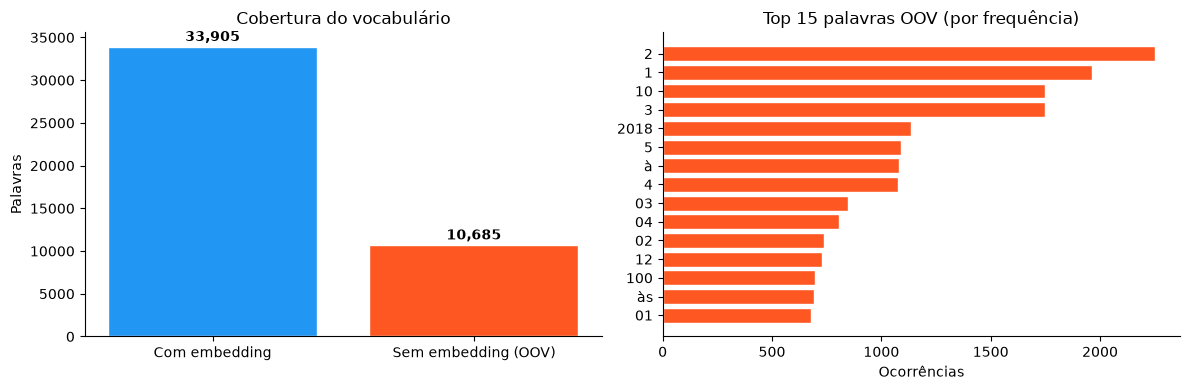

In [25]:
# cobertura dos embeddings por frequência no vocabulário
word_counts = tokenizer_lstm.word_counts
found_words = []
oov_words = []

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if embeddings_dict.get(word) is not None:
        found_words.append((word, word_counts.get(word, 0)))
    else:
        oov_words.append((word, word_counts.get(word, 0)))

oov_words.sort(key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels_cov = ["Com embedding", "Sem embedding (OOV)"]
sizes = [len(found_words), len(oov_words)]
colors = ["#2196F3", "#FF5722"]
axes[0].bar(labels_cov, sizes, color=colors, edgecolor="white")
for i, v in enumerate(sizes):
    axes[0].text(i, v + max(sizes)*0.02, f"{v:,}", ha="center", fontsize=10, weight="bold")
axes[0].set_title("Cobertura do vocabulário")
axes[0].set_ylabel("Palavras")
axes[0].spines[["top", "right"]].set_visible(False)

top_oov = oov_words[:15]
if top_oov:
    oov_labels = [w for w, _ in reversed(top_oov)]
    oov_counts = [c for _, c in reversed(top_oov)]
    axes[1].barh(oov_labels, oov_counts, color="#FF5722", edgecolor="white")
    axes[1].set_title("Top 15 palavras OOV (por frequência)")
    axes[1].set_xlabel("Ocorrências")
    axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()

### 3.4.3. Arquitetura do modelo

A rede recebe sequências de índices, converte cada índice no vetor de embedding correspondente (camada `Embedding` com pesos congelados), e passa a sequência de vetores por uma camada LSTM. A saída do LSTM alimenta uma camada densa com `softmax` que produz a probabilidade de cada classe (1 a 5 estrelas).

Ajuste os hiperparâmetros abaixo para tentar melhorar o desempenho do seu modelo.

In [26]:
LSTM_UNITS = 64  #@param [32, 64, 128] {type: "raw"}
DROPOUT = 0.3  #@param {type: "number"}
RECURRENT_DROPOUT = 0.0  #@param {type: "number"}
LEARNING_RATE = 1e-3  #@param {type: "number"}
USE_CLASS_WEIGHTS = False  #@param {type: "boolean"}

In [27]:
inp = Input(shape=(MAX_LEN,))

x = Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False
)(inp)
x = SpatialDropout1D(DROPOUT)(x)
x = LSTM(LSTM_UNITS, recurrent_dropout=RECURRENT_DROPOUT)(x)
x = Dropout(DROPOUT)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inp, output)

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=Adam(learning_rate=LEARNING_RATE),
    metrics=["accuracy"]
)

W0000 00:00:1787447469.098236   79948 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [28]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 300)       │    13,377,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 300)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,471,065 (51.39 MB)

 Trainable params: 93,765 (366.27 KB)

 Non-trainable params: 13,377,300 (51.03 MB)

### 3.4.4. Treinamento

O treinamento usa **early stopping**: se a loss de validação parar de melhorar por 2 épocas consecutivas, o treino para automaticamente e restaura os pesos da melhor época. Isso evita overfitting sem precisar adivinhar o número exato de épocas.

In [29]:
EPOCHS = 10  #@param {type: "integer"}
BATCH_SIZE = 256  #@param {type: "integer"}

In [30]:
class_weight = None
if USE_CLASS_WEIGHTS:
    weights = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=y_train_lstm)
    class_weight = dict(enumerate(weights))
    print(f"Class weights: {class_weight}")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train_lstm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 34s 93ms/step - accuracy: 0.4729 - loss: 1.2378 - val_accuracy: 0.5261 - val_loss: 1.0648
Epoch 2/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.5276 - loss: 1.0739 - val_accuracy: 0.5330 - val_loss: 1.0420
Epoch 3/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 33s 92ms/step - accuracy: 0.5482 - loss: 1.0218 - val_accuracy: 0.5598 - val_loss: 0.9768
Epoch 4/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.5623 - loss: 1.0011 - val_accuracy: 0.5683 - val_loss: 0.9612
Epoch 5/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.5735 - loss: 0.9774 - val_accuracy: 0.5824 - val_loss: 0.9399
Epoch 6/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.5868 - loss: 0.9555 - val_accuracy: 0.5895 - val_loss: 0.9402
Epoch 7/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.5912 - loss: 0.9431 - val_accuracy: 0.5916 - val_loss: 0.9339
Epoch 8/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.5969 - loss: 0.9311 - 

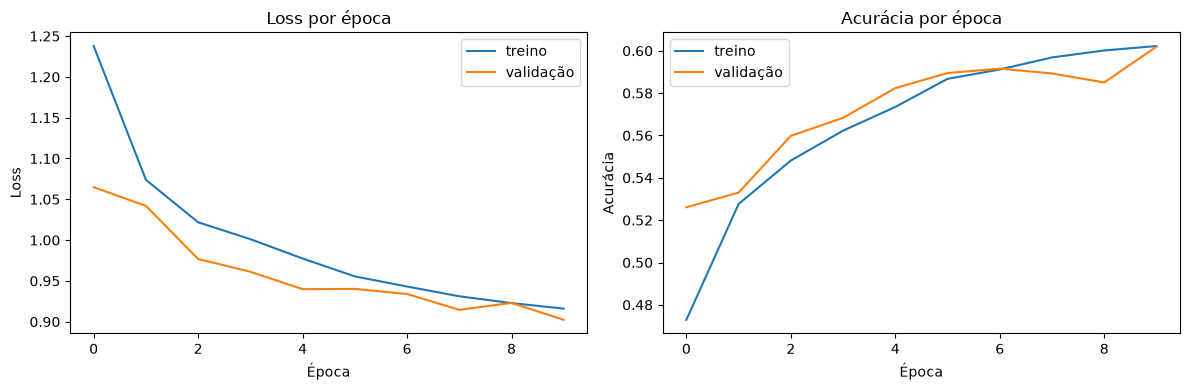

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="treino")
axes[0].plot(history.history["val_loss"], label="validação")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].set_title("Loss por época")

axes[1].plot(history.history["accuracy"], label="treino")
axes[1].plot(history.history["val_accuracy"], label="validação")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].legend()
axes[1].set_title("Acurácia por época")

plt.tight_layout()

**Checkpoint (Plano B):** se a sessão do Colab caiu ou o treino não completou a tempo, execute a célula abaixo para carregar um modelo pré-treinado com os hiperparâmetros padrão. Todos partem do mesmo piso — a vantagem competitiva vem de quem ajustou os hiperparâmetros.

In [32]:
# ⚠️ execute esta célula APENAS se precisar carregar o modelo pré-treinado

# CHECKPOINT_URL = "SEU_LINK_AQUI"  # TODO: substituir pelo link real
# !gdown {CHECKPOINT_URL} -O checkpoint_lstm_default.weights.h5
# model.load_weights("checkpoint_lstm_default.weights.h5")
# print("Pesos do checkpoint carregados.")

### 3.4.5. Avaliação

A métrica de ranking da competição é o **QWK** (Quadratic Weighted Kappa), que penaliza erros proporcionalmente à distância entre classes — errar 5→1 custa muito mais que errar 5→4. Macro-F1 e MAE aparecem como contexto e critério de desempate.

In [33]:
y_pred_proba = model.predict(X_test_seq, batch_size=BATCH_SIZE)
y_pred_cls = y_pred_proba.argmax(axis=1)

y_test_stars = y_test_lstm + 1
y_pred_stars = y_pred_cls + 1

qwk = cohen_kappa_score(y_test_stars, y_pred_stars, weights="quadratic")
macro_f1 = f1_score(y_test_stars, y_pred_stars, average="macro")
mae = mean_absolute_error(y_test_stars, y_pred_stars)

print(f"QWK (Quadratic Weighted Kappa): {qwk:.4f}")
print(f"Macro-F1:                       {macro_f1:.4f}")
print(f"MAE (Mean Absolute Error):      {mae:.4f}")
print()
print(classification_report(
    y_test_stars, y_pred_stars,
    target_names=[f"{i}★" for i in range(1, 6)]
))

99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step
QWK (Quadratic Weighted Kappa): 0.8299
Macro-F1:                       0.4890
MAE (Mean Absolute Error):      0.5202

              precision    recall  f1-score   support

          1★       0.71      0.92      0.80      4910
          2★       0.31      0.12      0.18      1595
          3★       0.46      0.37      0.41      3162
          4★       0.46      0.27      0.34      6342
          5★       0.63      0.81      0.71      9276

    accuracy                           0.60     25285
   macro avg       0.51      0.50      0.49     25285
weighted avg       0.56      0.60      0.57     25285



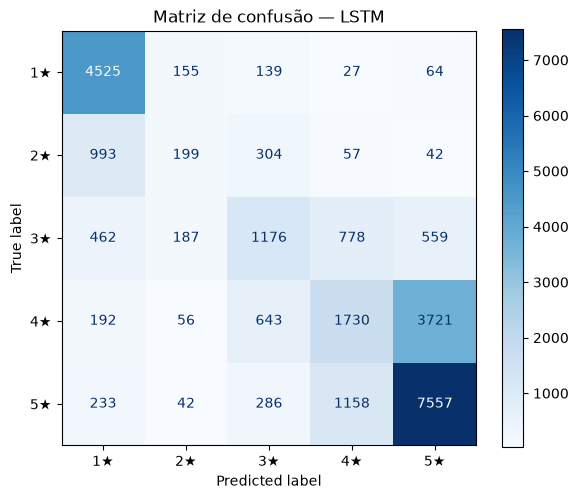

In [34]:
cm = confusion_matrix(y_test_stars, y_pred_stars)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=[f"{i}★" for i in range(1, 6)])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Matriz de confusão — LSTM")
plt.tight_layout()

### 3.4.6. Submissão para o leaderboard

A célula a seguir gera as predições sobre o conjunto de leaderboard e cria o arquivo CSV para submissão via Google Form.

In [35]:
X_lb_seq = pad_sequences(
    tokenizer_lstm.texts_to_sequences(df_leaderboard["review_text"]),
    maxlen=MAX_LEN, padding="post", truncating="post"
)

y_lb_pred = model.predict(X_lb_seq, batch_size=BATCH_SIZE).argmax(axis=1) + 1

submission = pd.DataFrame({
    "review_id": df_leaderboard["review_id"],
    "predicted_rating": y_lb_pred,
    "pipeline_used": "WE+LSTM"
})

submission.to_csv("submission_lstm.csv", index=False)
print(f"Arquivo de submissão gerado: submission_lstm.csv ({len(submission)} predições)")
submission.head(10)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Arquivo de submissão gerado: submission_lstm.csv (300 predições)


,review_id,predicted_rating,pipeline_used
0,92870,1,WE+LSTM
1,46191,1,WE+LSTM
2,17439,5,WE+LSTM
3,97410,3,WE+LSTM
4,129713,1,WE+LSTM
5,72337,4,WE+LSTM
6,90633,5,WE+LSTM
7,11452,4,WE+LSTM
8,101794,5,WE+LSTM
9,118187,5,WE+LSTM


## 3.5. Pipeline 3: Zero-shot com Gemini

Sem treino, sem dados rotulados, sem feature engineering — apenas uma instrução em linguagem natural. O modelo recebe a review e devolve uma nota de 1 a 5.

O objetivo aqui não é competir com os pipelines anteriores, mas provocar a pergunta: **se um LLM generalista já resolve, por que treinar um modelo específico?** A resposta está no custo por predição, na latência, na dependência de API externa e na controlabilidade.

### 3.5.1. Configuração da API

Cada participante usa **sua própria chave de API** do Google AI Studio. Se ainda não tem, crie em [aistudio.google.com/apikey](https://aistudio.google.com/apikey).

In [36]:
from pathlib import Path

for line in Path(".env").read_text().splitlines():
    line = line.strip()
    if line and not line.startswith("#") and "=" in line:
        key, _, value = line.partition("=")
        os.environ[key.strip()] = value.strip()

In [49]:
import google.generativeai as genai
# from google.colab import userdata

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")  #@param {type: "string"}
# GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")  #@param {type: "string"}
GEMINI_MODEL = "gemini-3.5-flash-lite"  #@param ["gemini-3.6-flash", "gemini-3.6-flash-lite"] {type: "string"}

genai.configure(api_key=GEMINI_API_KEY)
gemini = genai.GenerativeModel(GEMINI_MODEL)

print(f"Modelo configurado: {GEMINI_MODEL}")

Modelo configurado: gemini-3.5-flash-lite


### 3.5.2. Classificação zero-shot

O prompt pede ao modelo que retorne **apenas o número** da nota (1 a 5). Processamos uma amostra do conjunto de teste para manter o tempo e o custo razoáveis.

In [ ]:
import time

GEMINI_SAMPLE_SIZE = 200  #@param {type: "integer"}
REQUESTS_PER_MINUTE = 14  #@param {type: "integer"}

PROMPT_TEMPLATE = """Você é um classificador de sentimento para reviews de e-commerce brasileiro.
Dada a review abaixo, atribua uma nota de 1 a 5 estrelas, onde:
- 1 = péssimo
- 2 = ruim
- 3 = neutro
- 4 = bom
- 5 = excelente

Responda APENAS com o número (1, 2, 3, 4 ou 5), sem explicação.

Review: {review}"""

delay = 60.0 / REQUESTS_PER_MINUTE
estimated_min = GEMINI_SAMPLE_SIZE * delay / 60
print(f"Ritmo: {REQUESTS_PER_MINUTE} req/min (~{estimated_min:.1f} min para {GEMINI_SAMPLE_SIZE} reviews)")

df_gemini_sample = df_test.sample(n=min(GEMINI_SAMPLE_SIZE, len(df_test)), random_state=RANDOM_STATE)
y_true_gemini = df_gemini_sample["overall_rating"].values
y_pred_gemini = []
errors = 0
t_start = time.time()

for i, (_, row) in enumerate(df_gemini_sample.iterrows()):
    for attempt in range(3):
        try:
            response = gemini.generate_content(
                PROMPT_TEMPLATE.format(review=row["review_text"][:500]),
                generation_config=genai.GenerationConfig(temperature=0, max_output_tokens=5)
            )
            rating = int(response.text.strip())
            rating = max(1, min(5, rating))
            break
        except Exception as e:
            if "429" in str(e) and attempt < 2:
                time.sleep(45)
                continue
            rating = 3
            errors += 1
            break
    y_pred_gemini.append(rating)

    if (i + 1) % 50 == 0:
        elapsed = time.time() - t_start
        print(f"  {i + 1}/{len(df_gemini_sample)} ({elapsed:.0f}s)")

    time.sleep(delay)

elapsed = time.time() - t_start
y_pred_gemini = np.array(y_pred_gemini)
print(f"Concluído em {elapsed:.0f}s: {len(y_pred_gemini)} predições ({errors} erros, fallback para 3).")

Ritmo: 14 req/min (~14.3 min para 200 reviews)
  50/200 (275s)
  100/200 (627s)
  150/200 (894s)
  200/200 (1336s)
Concluído em 1340s: 200 predições (0 erros, fallback para 3).
Log salvo em: gemini_log.txt


### 3.5.3. Avaliação

Comparamos o Gemini com os pipelines anteriores usando as mesmas métricas. Lembre-se: este QWK é sobre uma **amostra** do teste, não sobre o conjunto completo.

=== Zero-shot Gemini (gemini-3.5-flash-lite) ===
Amostra: 200 reviews
QWK:      0.8779
Macro-F1: 0.5974
MAE:      0.3900

              precision    recall  f1-score   support

           1     0.8108    0.8824    0.8451        34
           2     0.3000    0.5000    0.3750         6
           3     0.6316    0.3636    0.4615        33
           4     0.7000    0.4038    0.5122        52
           5     0.6827    0.9467    0.7933        75

    accuracy                         0.6850       200
   macro avg     0.6250    0.6193    0.5974       200
weighted avg     0.6891    0.6850    0.6617       200



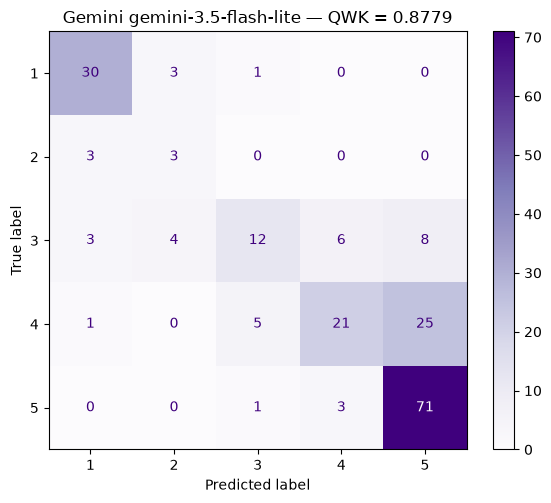

In [52]:
qwk_gemini = cohen_kappa_score(y_true_gemini, y_pred_gemini, weights="quadratic")
f1_gemini = f1_score(y_true_gemini, y_pred_gemini, average="macro")
mae_gemini = mean_absolute_error(y_true_gemini, y_pred_gemini)

print(f"=== Zero-shot Gemini ({GEMINI_MODEL}) ===")
print(f"Amostra: {len(y_true_gemini)} reviews")
print(f"QWK:      {qwk_gemini:.4f}")
print(f"Macro-F1: {f1_gemini:.4f}")
print(f"MAE:      {mae_gemini:.4f}")
print()
print(classification_report(y_true_gemini, y_pred_gemini, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_true_gemini, y_pred_gemini, ax=ax, cmap="Purples")
ax.set_title(f"Gemini {GEMINI_MODEL} — QWK = {qwk_gemini:.4f}")
plt.tight_layout()
plt.show()

### 3.5.4. Comparação entre pipelines

Cada pipeline tem um perfil diferente de custo-benefício. Nenhum é universalmente melhor — a escolha depende do cenário de uso.

In [ ]:
comparison = pd.DataFrame({
    "Pipeline": ["TF-IDF + LogReg", "Embeddings + LSTM", f"Gemini ({GEMINI_MODEL})"],
    "QWK": [qwk_lr, qwk, qwk_gemini],
    "Macro-F1": [f1_lr, macro_f1, f1_gemini],
    "MAE": [mae_lr, mae, mae_gemini],
    "Treino": ["~segundos", "~minutos", "zero"],
    "Custo/predição": ["zero", "zero", "API paga"],
})

comparison.style.highlight_max(
    subset=["QWK", "Macro-F1"], color="#d4edda"
).highlight_min(
    subset=["MAE"], color="#d4edda"
)

## 3.6. Detecção de incoerência

# 4. Fechamento